# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SymbolPamnani/Flyrank-ML-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can a content-prioritization ranking system identify pages that are more strongly associated with a dataset-defined decline trend, so that an SEO or content team can prioritize pages for human review?

### Decision supported

The practical decision is which content pages should be reviewed first for possible refresh.

The output is a ranked review queue rather than an automatic refresh decision.

### Unit of analysis

One pseudonymized content item/page.

### Why ML helps

The dataset contains multiple metadata signals describing search demand, competition, content characteristics, age, freshness, and intent. A ranking model can combine these signals into a single priority score instead of relying on one rule alone.

The work is intended as decision-support. It does not predict Google's ranking algorithm, prove that a page needs a refresh, or establish that refreshing a page will improve future performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data
The analysis uses the FlyRank internship starter dataset containing 30,000 pseudonymized content items and 44 columns across 32 pseudonymized clients.

The dataset contains 90-day aggregate performance fields as well as latest-30-day and previous-30-day measurements. The available schema does not provide exact historical timestamps for every field, so the reporting windows are described from the fields provided rather than assuming calendar boundaries that are not present.

### Target / proxy

For evaluation, I define a decline proxy as:

`trend_direction == "down"`

This is a dataset-defined proxy based on the observed trend category. It is not an independently observed future outcome.

The resulting decline-proxy rate is 54.2% across the full dataset.

### Features used

The final model uses 14 source features:

**Numeric**
- `search_volume`
- `competition`
- `cpc`
- `word_count`
- `char_count`
- `content_age_days`
- `days_since_last_update`

**Categorical**
- `competition_level`
- `content_type`
- `main_intent`
- `age_tier`
- `freshness_tier`
- `word_count_tier`
- `char_count_tier`

### Deliberately excluded

I excluded `trend_direction` and `trend_pct` because they define or directly encode the decline proxy.

I also excluded:
- latest/previous 30-day performance fields
- overlapping 90-day performance fields
- `impression_tier`
- `position_tier`
- `provider_used`
- `model_used`
- `content_id`
- `client_id`

The identifiers were used only for grouping and validation, not as model features.

The leakage audit found no forbidden fields in the final feature set.

A deliberate leakage test using `trend_pct` alone produced an accuracy of 1.000, demonstrating why that field must not be used as a model feature.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

### Task formulation

The task is ranking/scoring rather than binary classification for an operational decision.

The model produces a score that can be used to rank pages for review.

### Baseline

I first built a transparent rule-based baseline using three metadata signals:

- search-volume percentile: 50%
- days-since-last-update percentile: 30%
- content-age percentile: 20%

The baseline is intentionally simple and interpretable. It provides a reference against which the learned model can be evaluated.

### Learned model

I used Logistic Regression as the first learned model.

It was selected because it is relatively simple, interpretable, and produces a score that can be used for ranking.

Numeric features were median-imputed with missingness indicators and standardized.

Categorical features were imputed and one-hot encoded with unknown-category handling.

The Logistic Regression model used balanced class weights, `max_iter=2000`, and `random_state=42`.

### Validation design

The primary evaluation uses a client-grouped 80/20 holdout.

The training set contains 25 clients and 23,837 rows.

The test set contains 7 previously unseen clients and 6,163 rows.

There is no client overlap between training and test.

This is stricter than a row-random split because content from the same client cannot appear in both training and test.

### Primary metric

The primary metric is Precision@50.

This measures the proportion of the top 50 ranked pages that belong to the decline-proxy class.

The metric matches the operational use case because the content team is expected to review a limited number of pages first.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results (vs baseline)

The final evaluation compares the learned model and the transparent W04 rule baseline on the same client-grouped test set.

| Method | Precision@20 | Precision@50 |
|---|---:|---:|
| Declining-proxy base rate | 0.511 | 0.511 |
| W04 Rule Baseline | 0.500 | 0.400 |
| Logistic Regression | 0.300 | 0.380 |

The client-grouped test set has a decline-proxy base rate of 0.511.

At Precision@50, the transparent baseline measured 0.400 and Logistic Regression measured 0.380.

Therefore, in this evaluation, the learned Logistic Regression model did not outperform the simple rule baseline.

The model also did not exceed the decline-proxy base rate at Precision@50.

These are measured results on the held-out client set and should not be interpreted as evidence about future performance without a time-forward evaluation.

## 5. Limitations

*What this work cannot claim.*

## Limitations

Several limitations constrain the interpretation of this work.

First, the target is a dataset-defined decline proxy based on `trend_direction`, rather than a future outcome observed after the prediction point.

Second, the evaluation is client-grouped but not fully time-forward. A future time-aware evaluation would provide stronger evidence about whether the ranking transfers to genuinely future decline outcomes.

Third, the measured relationships in the signal audit were generally weak. Search volume versus impressions had a correlation of 0.001, days since last update versus CTR had a correlation of -0.021, and content age versus CTR had a correlation of 0.009.

Fourth, the model produced 31 false positives among its top 50 ranked test items. This corresponds to a top-50 false-positive rate of 62%.

Finally, the analysis does not establish that content age, freshness, or any other feature causes decline, nor does it establish that refreshing a flagged page will improve search performance.

The output should therefore be treated as decision-support for human review rather than an automatic content-change system.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked recommendations

The final output is a ranked review queue containing 6,163 test-set pages.

Each page receives:
- a model score,
- a rank,
- an action,
- and a reason code.

The recommended action for the queue is:

**Review for refresh**

The highest-ranked pages should be reviewed first, but ranking position does not establish that a page will decline or that it requires a refresh.

Reason codes provide observable context for human reviewers. The exported queue uses signals including:

- `OLD_CONTENT`
- `LOW_SEARCH_SIGNAL`
- `HIGH_COMPETITION`
- `STALE_CONTENT`
- `MODEL_PRIORITY`

The reason-code occurrence counts in the final queue were:

| Reason code | Occurrences |
|---|---:|
| OLD_CONTENT | 2,523 |
| LOW_SEARCH_SIGNAL | 1,835 |
| HIGH_COMPETITION | 1,427 |
| STALE_CONTENT | 966 |
| MODEL_PRIORITY | 950 |

A single page may receive multiple reason codes, so these occurrence counts are not expected to sum to the total queue size.

### Human review process

Before taking action, a reviewer should check:

1. Current search intent
2. Factual accuracy
3. Recent topic developments
4. Existing page performance
5. Content relevance
6. Potential risk of changing useful content

The system should not automatically delete pages, rewrite factual claims, change search intent, redirect pages, publish model-generated edits, or treat a high score as proof of future decline.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts the paper embeds

The paper should include three main artifacts.

### 1. Model versus baseline

A Precision@50 comparison showing the decline-proxy base rate, the transparent W04 baseline, and the Logistic Regression model on the same client-grouped test set.

### 2. Validation audit

A comparison between the row-random and client-grouped evaluations. The row-random split produced Precision@50 of 0.780, while the client-grouped evaluation produced 0.380. This demonstrates the importance of grouping by client when evaluating generalization across clients.

### 3. Action-queue reason distribution

A summary of the reason codes assigned to the ranked action queue. This gives the human reviewer additional context beyond the model score.

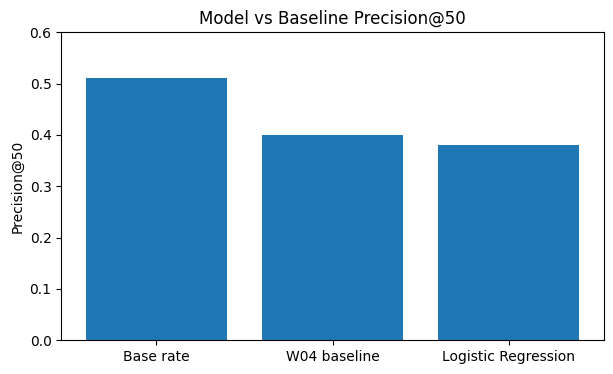

In [1]:
# Artifact 1.
### Model vs Baseline — Precision@50

import matplotlib.pyplot as plt

methods = ["Base rate", "W04 baseline", "Logistic Regression"]
scores = [0.511, 0.400, 0.380]

plt.figure(figsize=(7, 4))
plt.bar(methods, scores)
plt.ylabel("Precision@50")
plt.title("Model vs Baseline Precision@50")
plt.ylim(0, 0.6)
plt.show()

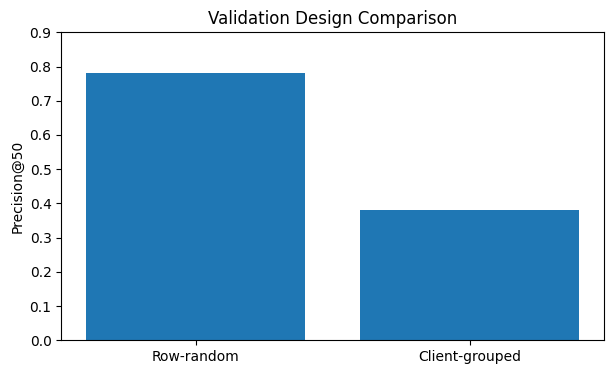

In [2]:
# Artifact 2
### Validation Design Comparison — Precision@50
import matplotlib.pyplot as plt

methods = ["Row-random", "Client-grouped"]
scores = [0.780, 0.380]

plt.figure(figsize=(7, 4))
plt.bar(methods, scores)
plt.ylabel("Precision@50")
plt.title("Validation Design Comparison")
plt.ylim(0, 0.9)
plt.show()

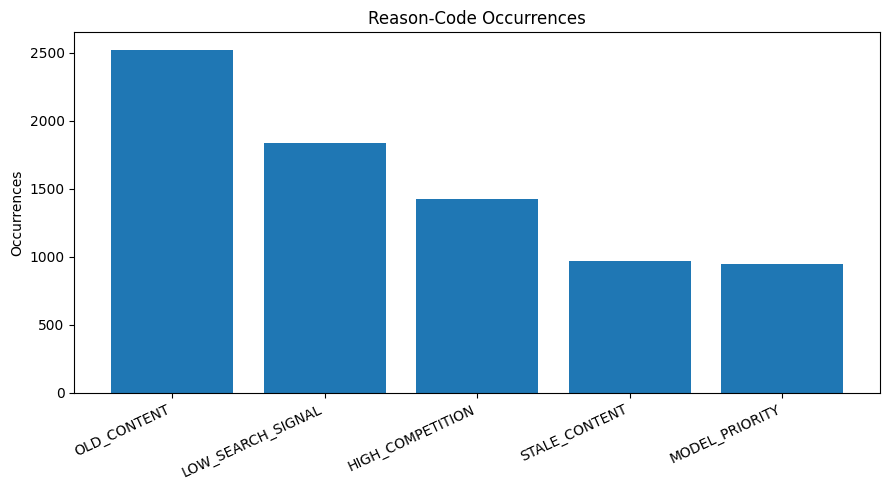

In [3]:
# Artifact 3
### Reason-Code Occurrences

import matplotlib.pyplot as plt

reason_codes = [
    "OLD_CONTENT",
    "LOW_SEARCH_SIGNAL",
    "HIGH_COMPETITION",
    "STALE_CONTENT",
    "MODEL_PRIORITY"
]

occurrences = [2523, 1835, 1427, 966, 950]

plt.figure(figsize=(9, 5))
plt.bar(reason_codes, occurrences)
plt.ylabel("Occurrences")
plt.title("Reason-Code Occurrences")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Problem

Explain the content-refresh prioritization problem and why an SEO/content team needs a ranked review queue.

### 0:45–1:30 — Data and target

Introduce the 30,000-page dataset, 32 pseudonymized clients, and the dataset-defined decline proxy.

### 1:30–2:15 — Baseline

Show the transparent W04 rule using search demand, freshness, and content age.

### 2:15–3:15 — Model and validation

Explain the Logistic Regression model and the client-grouped holdout.

Show the comparison:

- Base rate: 0.511
- Baseline Precision@50: 0.400
- Logistic Regression Precision@50: 0.380

### 3:15–4:00 — Validation and leakage

Show that the row-random split produced 0.780 while the client-grouped split produced 0.380.

Explain the deliberate `trend_pct` leakage test and why trend-derived fields were excluded.

### 4:00–5:00 — Action playbook

Show the ranked queue, reason codes, human-review checklist, and no-go automation list.

End with the main conclusion:

The learned model did not outperform the transparent baseline in this evaluation, so the output should remain decision-support for human review rather than an automatic refresh system.

# Social-Post Cut

Built an end-to-end ML workflow for content-refresh prioritization during the FlyRank ML Internship.

The project covered research-question framing, data contracts, leakage auditing, a transparent ranking baseline, signal testing, Logistic Regression, client-grouped validation, error analysis, and an action playbook.

One of the most useful findings was also one of the least glamorous: the learned model did not outperform the simple baseline on the honest client-grouped holdout.

That result reinforced an important ML lesson — a more complex model is not automatically a better decision tool.

The final system produces a ranked review queue with reason codes while keeping human review in the loop.

# Employer-Facing Summary

I built an end-to-end content-prioritization workflow that combines a transparent ranking baseline with an interpretable Logistic Regression model and client-grouped validation. The evaluation showed that the learned model achieved Precision@50 of 0.380 compared with 0.400 for the rule-based baseline, demonstrating why honest validation and baseline comparison matter. The final output is a reproducible review queue with reason codes and explicit safeguards against leakage, overclaiming, and automatic content decisions.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
